<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Fashion_MNIST2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project overview
The objective of this project is to develop, train and evaluate deep-learning models that classify grayscale images of fashion products into ten categories.
The project uses the Fashion-MNIST dataset, which contains \(28 * 28\)-pixel grayscale images of clothing and footwear.


This project will compare two deep-learning approaches:
1. A fully connected multilayer perceptron, or MLP
2. A convolutional neural network, or CNN


### Business-style problem definition
Imagine an online clothing retailer that receives large numbers of product images. Each image must be assigned to a product category before it can be displayed, searched or recommended to customers.
Manually assigning these categories would be:
- Slow
- Expensive
- Inconsistent
- Difficult to scale
The machine-learning task is therefore to create an automated image-classification system that predicts the correct product category from a grayscale image.


### Machine-learning problem
This is a supervised multiclass image-classification problem.
For every image, the model predicts one of ten possible classes from 0 to 9.

### Dataset
- Fashion-MNIST contains 70,000 grayscale images.
- Dataset portion	Number of images
- Original training set	60,000
- Original test set	10,000
- Image size	(28 * 28)
- Number of classes	10


Each pixel has an intensity value between 0 and 255.

Class definitions

Label	Product category
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot


The dataset can be loaded directly through Keras:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = (
    fashion_mnist.load_data()
)

#Main project objective
The main objective is to build a deep-learning model that accurately classifies Fashion-MNIST images while maintaining good performance on previously unseen data.

The project should answer the following questions:
1. Can a neural network classify the ten fashion categories reliably?
2. How does an MLP compare with a CNN?
3. Which product categories are most difficult to distinguish?
7. How confident is the model when it makes incorrect predictions?

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.layers import Conv2D, MaxPooling2D, SpatialDropout2D, Flatten

In [87]:
(x_train_val, y_train_val), (x_test, y_test) = fashion_mnist.load_data()

In [88]:
print(x_train_val.shape)
print(y_train_val.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [89]:

# Checking the nan cells in the data

print('Any NAN in the train_validation data?  ', np.isnan(x_train_val).any())
print('Any NAN in the test data?  ', np.isnan(x_test).any())
print('Any NAN in the train_validation labels?  ', np.isnan(y_train_val).any())
print('Any NAN in the test labels?  ', np.isnan(y_test).any())

Any NAN in the train_validation data?   False
Any NAN in the test data?   False
Any NAN in the train_validation labels?   False
Any NAN in the test labels?   False


In [90]:
# Checking the manimum and maximum values at each set of data

print('Minimum and maximum values of train_val set:')
print(np.min(x_train_val, axis = (0, 1, 2)), np.max(x_train_val, axis = (0, 1, 2)))

print('Minimum and maximum values of test set:')
print(np.min(x_test, axis = (0, 1, 2)), np.max(x_test, axis = (0, 1, 2)))

Minimum and maximum values of train_val set:
0 255
Minimum and maximum values of test set:
0 255


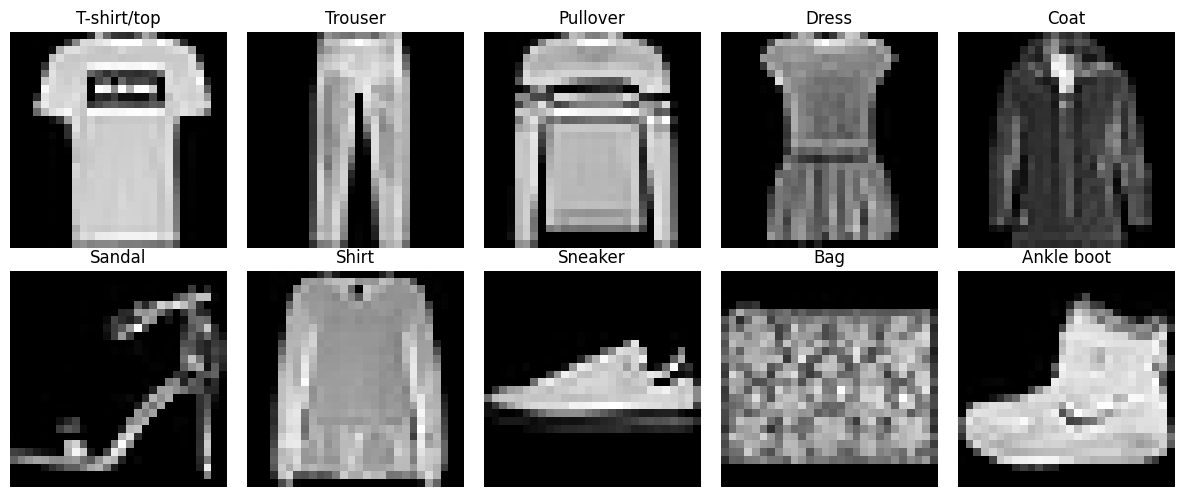

In [91]:
# Visualizing some example images

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize = (12, 5))
for label, ax in enumerate(axes.ravel()):
  index = np.where(y_train_val == label)[0][0]
  ax.imshow(x_train_val[index], cmap = 'gray')
  ax.set_title(class_names[label])
  ax.axis('off')
plt.tight_layout()
plt.show()

In [92]:
# Seeing the frequency of labels

print('label frequency in train_val labels:\n  ', np.unique(y_train_val, return_counts = True))
print('label frequency in test labels:\n  ', np.unique(y_test, return_counts = True))


label frequency in train_val labels:
   (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))
label frequency in test labels:
   (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))


The result above shows that the frequency of the labels at each set of data is the same.

Now, we should consider a baseline model. Based on the balanced characteristic of the data, only one-class guess gives us 6000 true class prediction and 9 * 6000 = 54000 false predictions. In this case, the accuracy is 0.1.

A classic machine learning model like multinomial logistic regression is a more sophisticated model that comes below:


In [93]:
# The classic basline model requires the input data as tabular. Therefore, the image
# data must be flattened.

x_train_val_flat = x_train_val.reshape(x_train_val.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)
print(x_train_val_flat.shape, x_test_flat.shape)

(60000, 784) (10000, 784)


In [94]:
# Splitting the train_val section into separate train and validation parts.
# Note that we keep the balance of labels even after splitting the data


x_train1, x_val1, y_train1, y_val1 = train_test_split(x_train_val_flat, y_train_val,
                                                    test_size = 0.2, stratify = y_train_val,
                                                      random_state = 42)

x_test1 = x_test_flat.copy()

print(x_train1.shape, x_val1.shape)
print(y_train1.shape, y_val1.shape)


(48000, 784) (12000, 784)
(48000,) (12000,)


In [95]:
# Now the data should be normalized the data.
# It must be noted that since each image is normalized between 0 and 1, this normalization could
# have been performed even before splitting train_val dataset.

x_train1 = (x_train1 - np.min(x_train1, axis = 1, keepdims = True)) / (np.max(x_train1,
                   axis = 1, keepdims = True) - np.min(x_train1, axis = 1, keepdims = True))

x_val1 = (x_val1 - np.min(x_val1, axis = 1, keepdims = True)) / (np.max(x_val1,
                   axis = 1, keepdims = True) - np.min(x_val1, axis = 1, keepdims = True))

x_test1 = (x_test1 - np.min(x_test1, axis = 1, keepdims = True)) / (np.max(x_test1,
                   axis = 1, keepdims = True) - np.min(x_test1, axis = 1, keepdims = True))

In [96]:
np.min(x_val1), np.max(x_val1)

(np.float64(0.0), np.float64(1.0))

In [97]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(max_iter = 100, random_state = 42)
model1.fit(x_train1, y_train1)
y_pred1 = model1.predict(x_test1)
print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1000
           1       0.97      0.95      0.96      1000
           2       0.72      0.72      0.72      1000
           3       0.83      0.87      0.85      1000
           4       0.73      0.77      0.75      1000
           5       0.94      0.92      0.93      1000
           6       0.62      0.56      0.59      1000
           7       0.91      0.93      0.92      1000
           8       0.93      0.94      0.94      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#  Model 2: A fully connected multilayer perceptron, or MLP


In [98]:
# Creating the architecture of the fully connected model (model 1)


model2 = Sequential([
    Input (shape = (x_train1.shape[1], ), name = 'input'),

    Dense (128, activation = 'relu', kernel_initializer= 'he_normal'),
    BatchNormalization(),
    Dropout(0.3),

    Dense (64, activation = 'relu', kernel_initializer= 'he_normal'),
    BatchNormalization(),
    Dropout(0.3),

    Dense (32, activation = 'relu', kernel_initializer= 'he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense (10, activation = 'softmax', kernel_initializer = 'glorot_normal', name = 'output')
])

In [99]:
model2.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [100]:
# Defining the callback metrics

ES2 = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    patience = 8,
    restore_best_weights = True
)

MC2 = ModelCheckpoint(
    'best_model1.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)

LR2 = ReduceLROnPlateau(
    monitor = 'val_loss',
    mode = 'min',
    patience = 5,
    factor = 0.5
)



In [101]:
# Fitting the model

HISTORY2 = model2.fit(x_train1, y_train1,
          validation_data = (x_val1, y_val1),
          epochs = 100,
          batch_size = 128,
          callbacks = [ES2, MC2, LR2],
          verbose = 1
          )

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7066 - loss: 0.8722 - val_accuracy: 0.8261 - val_loss: 0.4832 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8046 - loss: 0.5697 - val_accuracy: 0.8531 - val_loss: 0.4083 - learning_rate: 0.0010
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8235 - loss: 0.5101 - val_accuracy: 0.8373 - val_loss: 0.4254 - learning_rate: 0.0010
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8339 - loss: 0.4829 - val_accuracy: 0.8657 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8389 - loss: 0.4661 - val_accuracy: 0.8708 - val_loss: 0.3680 - learning_rate: 0.0010
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8470 - loss: 0.4498 - val_accuracy: 0.8662 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8509 - 

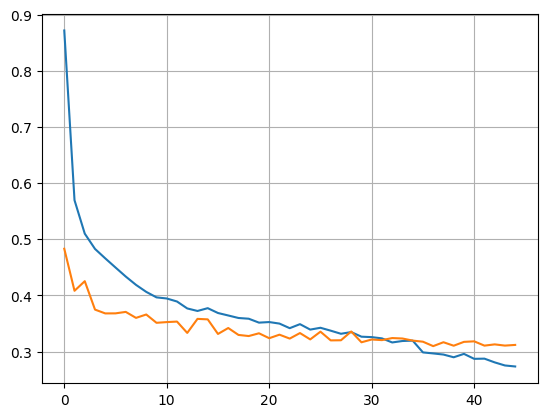

In [102]:
# Plotting the loss curves

plt.plot(HISTORY2.history['loss'])
plt.plot(HISTORY2.history['val_loss'])
plt.grid()

In [103]:
predictions2 = model2.predict(x_test1)
y_pred2 = np.argmax(predictions2, axis = 1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


#  Model 3: Convolutional Neural Network

In [56]:
# Splitting the train-validation dataset into train and validation sets.

x_train2, x_val2, y_train2, y_val2 = train_test_split(x_train_val, y_train_val, test_size = 0.2,
                                                      stratify = y_train_val, random_state = 42)


'x_train2, x_val2, y_train2, y_val2 = train_test_split(x_train_val, y_train_val, test_size = 0.2, \n                                                      stratify = y_train_val, random_state = 42)'

In [57]:
# Normalizing the data per sample

x_train2 = (x_train2 - np.min(x_train2, axis = (1, 2), keepdims = True)) / (np.max(x_train2, axis = (1, 2), keepdims = True) -
                                                                    np.min(x_train2, axis = (1, 2), keepdims = True))

x_val2 = (x_val2 - np.min(x_val2, axis = (1, 2), keepdims = True)) / (np.max(x_val2, axis = (1, 2), keepdims = True) -
                                                                np.min(x_val2, axis = (1, 2), keepdims = True))


x_test2 = (x_test - np.min(x_test, axis = (1, 2), keepdims = True)) / (np.max(x_test, axis = (1, 2), keepdims = True) -
                                                                  np.min(x_test, axis = (1, 2), keepdims = True))

'x_train2 = (x_train2 - np.min(x_train2, axis = (1, 2), keepdims = True)) / (np.max(x_train2, axis = (1, 2), keepdims = True) -\n                                                                    np.min(x_train2, axis = (1, 2), keepdims = True))\n\nx_val2 = (x_val2 - np.min(x_val2, axis = (1, 2), keepdims = True)) / (np.max(x_val2, axis = (1, 2), keepdims = True) -\n                                                                np.min(x_val2, axis = (1, 2), keepdims = True))\n\n\nx_test2 = (x_test - np.min(x_test, axis = (1, 2), keepdims = True)) / (np.max(x_test, axis = (1, 2), keepdims = True) -\n                                                                  np.min(x_test, axis = (1, 2), keepdims = True))'

In [104]:
# Architecture of the model

model3 = Sequential([
    Input (shape = (x_train2.shape[1], x_train2.shape[2], 1)),

    Conv2D(128, (3, 3), activation = 'relu', kernel_initializer = 'he_normal'),
    MaxPooling2D((2, 2)),
    SpatialDropout2D(0.3),

    Conv2D(64, (3, 3), activation = 'relu', kernel_initializer = 'he_normal'),
    MaxPooling2D((2, 2)),
    SpatialDropout2D(0.3),

    Flatten(),
    Dense(10, activation = 'softmax')
])

In [105]:
# Compiling the model

model3.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [106]:
# Defining the callback metrics

ES3 = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    patience = 8,
    restore_best_weights = True
)

MC3 = ModelCheckpoint(
    'best_model2.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)

LR3 = ReduceLROnPlateau(
    monitor = 'val_loss',
    mode = 'min',
    patience = 5,
    factor = 0.5
)


In [107]:
# Fitting the model

HISTORY3 = model3.fit(
    x_train2, y_train2,
    validation_data = (x_val2, y_val2),
    epochs = 10,
    batch_size = 128,
    callbacks = [ES3, MC3, LR3],
    verbose = 1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 165s 437ms/step - accuracy: 0.7770 - loss: 0.6261 - val_accuracy: 0.8597 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 188s 399ms/step - accuracy: 0.8534 - loss: 0.4083 - val_accuracy: 0.8808 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 200s 394ms/step - accuracy: 0.8686 - loss: 0.3652 - val_accuracy: 0.8895 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 144s 383ms/step - accuracy: 0.8781 - loss: 0.3377 - val_accuracy: 0.8936 - val_loss: 0.2983 - learning_rate: 0.0010
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 148s 394ms/step - accuracy: 0.8861 - loss: 0.3143 - val_accuracy: 0.8981 - val_loss: 0.2844 - learning_rate: 0.0010
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 201s 393ms/step - accuracy: 0.8910 - loss: 0.2993 - val_accuracy: 0.9039 - val_loss: 0.2734 - learning_rate: 0.0010
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 201s 390ms/step - accura

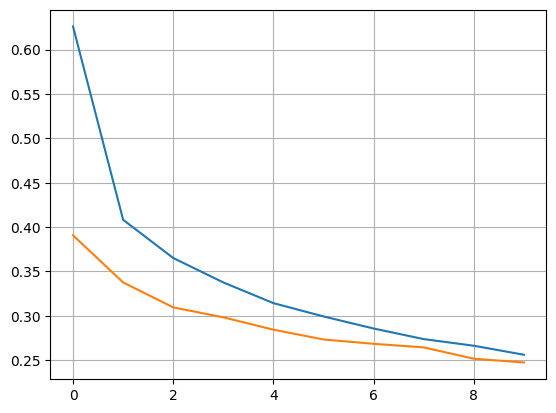

In [108]:
plt.plot(HISTORY3.history['loss'])
plt.plot(HISTORY3.history['val_loss'])
plt.grid()

In [109]:
predictions3 = model3.predict(x_test2)
y_pred3 = np.argmax(predictions3, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [110]:
# classification report of the logistic regression model

print(classification_report(y_test,
                            y_pred1,
                            target_names=class_names,
                            digits=4))


              precision    recall  f1-score   support

 T-shirt/top     0.8051    0.8140    0.8095      1000
     Trouser     0.9725    0.9540    0.9631      1000
    Pullover     0.7220    0.7220    0.7220      1000
       Dress     0.8309    0.8700    0.8500      1000
        Coat     0.7289    0.7690    0.7484      1000
      Sandal     0.9409    0.9230    0.9319      1000
       Shirt     0.6247    0.5560    0.5884      1000
     Sneaker     0.9086    0.9340    0.9211      1000
         Bag     0.9327    0.9420    0.9373      1000
  Ankle boot     0.9428    0.9400    0.9414      1000

    accuracy                         0.8424     10000
   macro avg     0.8409    0.8424    0.8413     10000
weighted avg     0.8409    0.8424    0.8413     10000



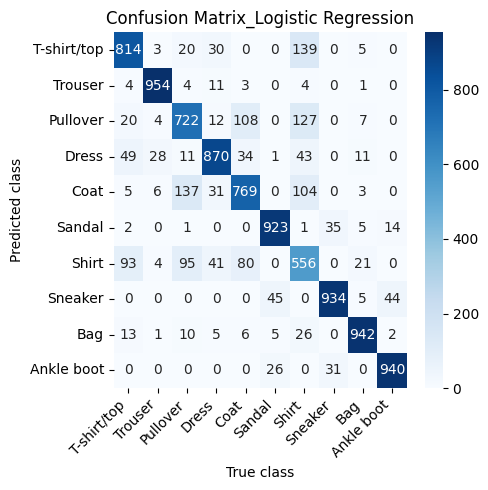

In [111]:

# Confusion matrix of the logistic regression model

import seaborn as sns

cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(5,5))

sns.heatmap(
    cm1.T,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel("Predicted class")
plt.xlabel("True class")
plt.title("Confusion Matrix_Logistic Regression")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [112]:
# Classification report of the MLP model

print(classification_report(y_test,
                            y_pred2,
                            target_names=class_names,
                            digits=4))

              precision    recall  f1-score   support

 T-shirt/top     0.8477    0.8180    0.8326      1000
     Trouser     0.9788    0.9710    0.9749      1000
    Pullover     0.7990    0.7870    0.7929      1000
       Dress     0.8898    0.8800    0.8849      1000
        Coat     0.7713    0.8330    0.8010      1000
      Sandal     0.9632    0.9690    0.9661      1000
       Shirt     0.7073    0.6840    0.6955      1000
     Sneaker     0.9366    0.9600    0.9481      1000
         Bag     0.9605    0.9730    0.9667      1000
  Ankle boot     0.9663    0.9450    0.9555      1000

    accuracy                         0.8820     10000
   macro avg     0.8820    0.8820    0.8818     10000
weighted avg     0.8820    0.8820    0.8818     10000



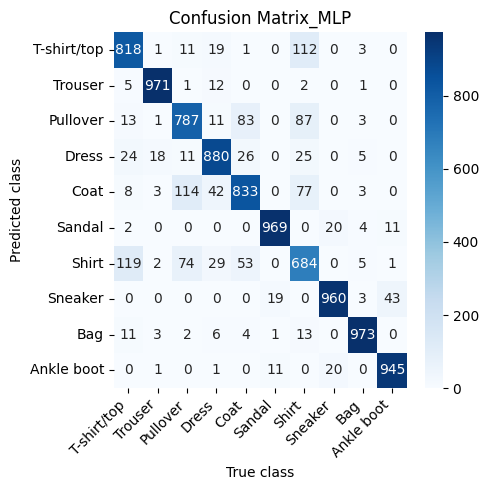

In [113]:
# Confusion matrix of MLP model

cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5,5))

sns.heatmap(
    cm2.T,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel("Predicted class")
plt.xlabel("True class")
plt.title("Confusion Matrix_MLP")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [81]:
# Classification report of the CNN model

print(classification_report(y_test,
                            y_pred3,
                            target_names=class_names,
                            digits=4))

'print(classification_report(y_val2,\n                            y_val3_pred, \n                            target_names=class_names,\n                            digits=4))\n'

In [ ]:

cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(5,5))

sns.heatmap(
    cm3.T,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel("Predicted class")
plt.xlabel("True class")
plt.title("Confusion Matrix_CNN")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()'''

The confusion matrices above show that the solution for CNN is the most accurate one. Almost all the metrics are better for deep learning, in particular, the CNN model. The non-diagonal elements reveal the misclassified items; some of the classes are more difficult to be predicted correctly than others. Shirt is one of these examples that is misclassifed as T-shirt/top, coat, and pullover. Other examples are coat, dress and T-shirt.
By contrasts, classes such as trousers, bags and ankle boots are easier to predict because their overall shapes are more distinctive.

In [83]:
# In this part we would like to see some examples of the wrong predictions attained
# from the CNN model and how confident the model is about them.

incorrect = np.where(y_pred3 != y_test)[0]
print(len(incorrect))

1349


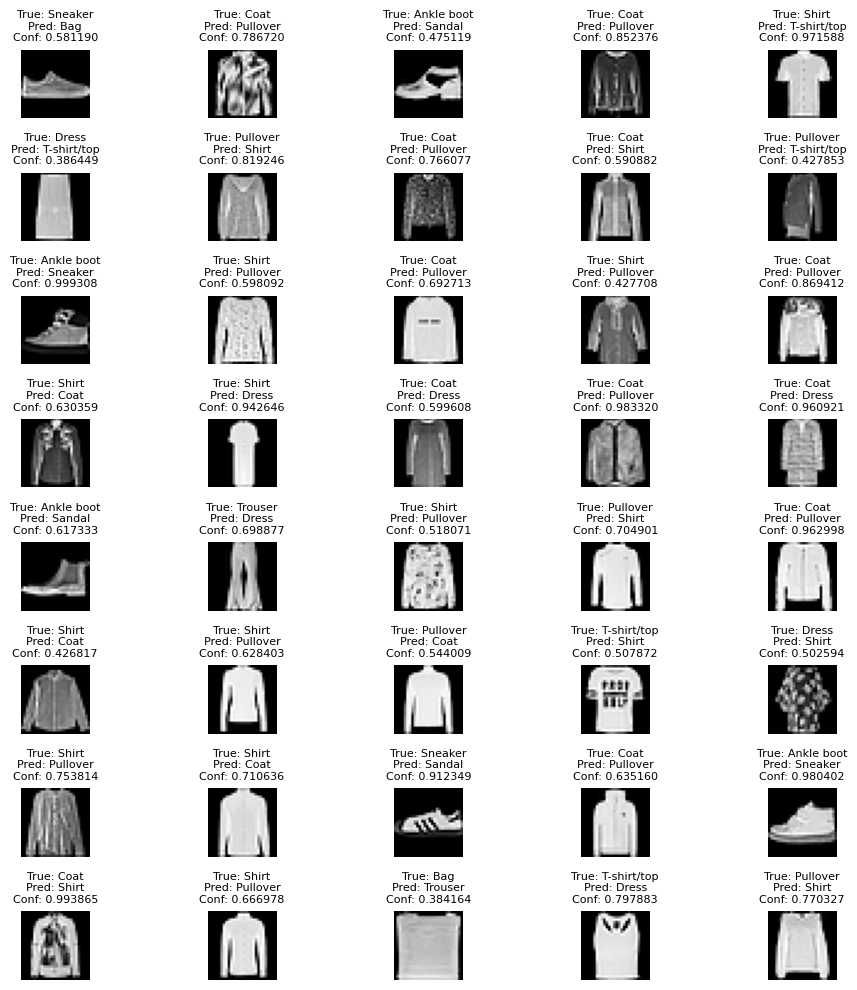

In [85]:

plt.figure(figsize = (10, 10))

for position, index in enumerate(incorrect[:40]):
  plt.subplot(8, 5, position + 1)
  plt.imshow(x_test[index], cmap = 'gray')

  confidence = predictions3[index, y_pred3[index]]
  plt.title(f"True: {class_names[y_test[index]]}\n"
            f"Pred: {class_names[y_pred3[index]]}\n"
            f"Conf: {confidence:02f}",
            fontsize = 8)
  plt.axis('off')

plt.tight_layout()
plt.show()
